In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("month-wise-duration.csv")
print(df.head())

       Month Total Uploaded Duration Total Created Duration  \
0  Apr, 2025                65:28:28               98:01:05   
1  Aug, 2025                39:56:34               64:31:04   
2  Dec, 2025                38:15:27               71:41:50   
3  Feb, 2026               161:52:11              301:30:46   
4  Jan, 2026               121:59:42              191:27:32   

  Total Published Duration  
0                 01:05:42  
1                 00:06:33  
2                 00:14:38  
3                 00:56:12  
4                 01:26:44  


In [4]:
df.tail()

,Month,Total Uploaded Duration,Total Created Duration,Total Published Duration
7,"Mar, 2025",122:03:35,176:16:55,00:00:00
8,"May, 2025",46:56:53,64:26:46,00:03:52
9,"Nov, 2025",48:06:54,83:22:47,00:02:13
10,"Oct, 2025",47:51:24,94:17:09,00:14:55
11,"Sep, 2025",34:21:14,58:38:05,00:00:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Month                     12 non-null     object
 1   Total Uploaded Duration   12 non-null     object
 2   Total Created Duration    12 non-null     object
 3   Total Published Duration  12 non-null     object
dtypes: object(4)
memory usage: 516.0+ bytes


In [6]:
print(df.isnull().sum())

Month                       0
Total Uploaded Duration     0
Total Created Duration      0
Total Published Duration    0
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Month                     12 non-null     object
 1   Total Uploaded Duration   12 non-null     object
 2   Total Created Duration    12 non-null     object
 3   Total Published Duration  12 non-null     object
dtypes: object(4)
memory usage: 516.0+ bytes


In [8]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Month                     12 non-null     int32
 1   Total Uploaded Duration   12 non-null     int32
 2   Total Created Duration    12 non-null     int32
 3   Total Published Duration  12 non-null     int32
dtypes: int32(4)
memory usage: 324.0 bytes


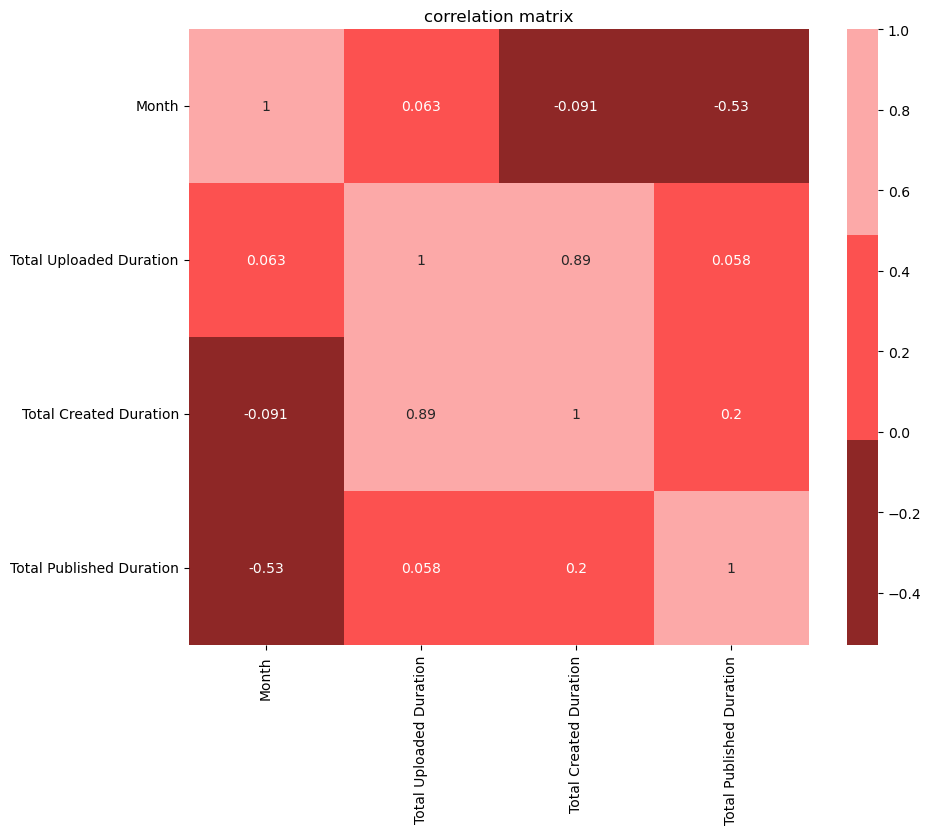

In [10]:
correlation_matrix = df.corr(numeric_only = 'True')
plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix,annot=True,cmap=(["#8E2726", "#FC5150", "#FCA9A8"]))
plt.title('correlation matrix')
plt.show()

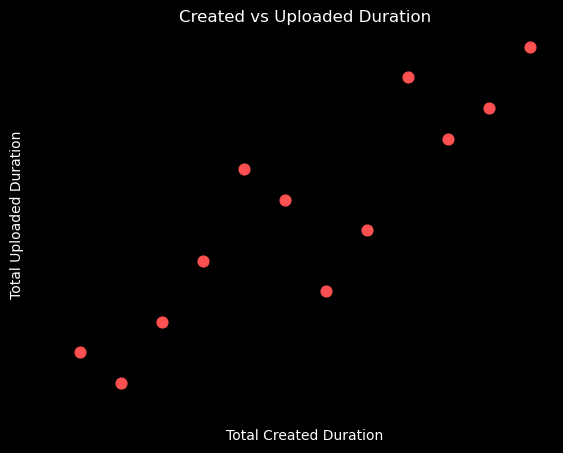

In [11]:
plt.figure(facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(df['Total Created Duration'], df['Total Uploaded Duration'],
            color='#FC5150', s=60)

plt.xlabel('Total Created Duration', color='white')
plt.ylabel('Total Uploaded Duration', color='white')
plt.title('Created vs Uploaded Duration', color='white')

plt.show()

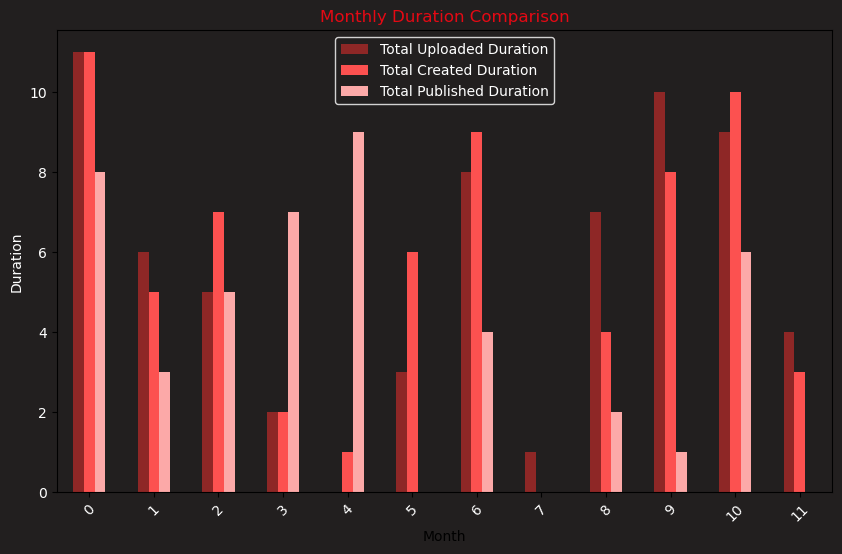

In [12]:
colors = ['#8E2726', '#FC5150', '#FCA9A8']  

ax = df.set_index('Month')[['Total Uploaded Duration',
                            'Total Created Duration',
                            'Total Published Duration']].plot(
                                kind='bar',
                                color=colors,
                                figsize=(10,6)
                            )

ax.set_facecolor('#221F1F')
plt.gcf().patch.set_facecolor('#221F1F')
plt.ylabel('Duration', color='white')
plt.title('Monthly Duration Comparison', color='#E50914')
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')
plt.legend(facecolor='#221F1F', edgecolor='white', labelcolor='white')
plt.show()

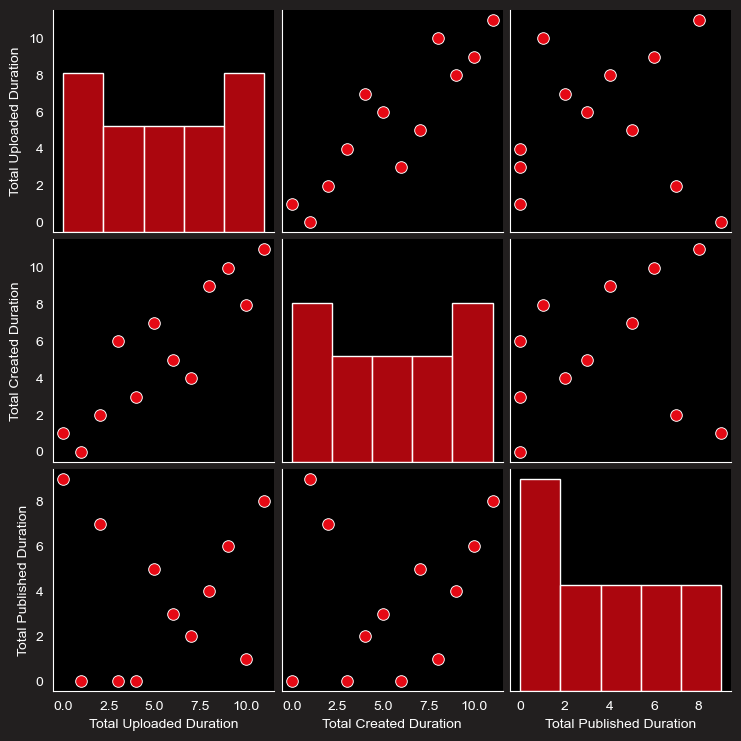

In [13]:
sns.set_style("dark")
plt.style.use("dark_background")
g = sns.pairplot(
    df[['Total Uploaded Duration',
        'Total Created Duration',
        'Total Published Duration']],
    plot_kws={'color': '#E50914', 's': 70},   # red scatter points
    diag_kws={'color': '#E50914'}             # red histogram
)
g.fig.patch.set_facecolor('#221F1F')
plt.show()

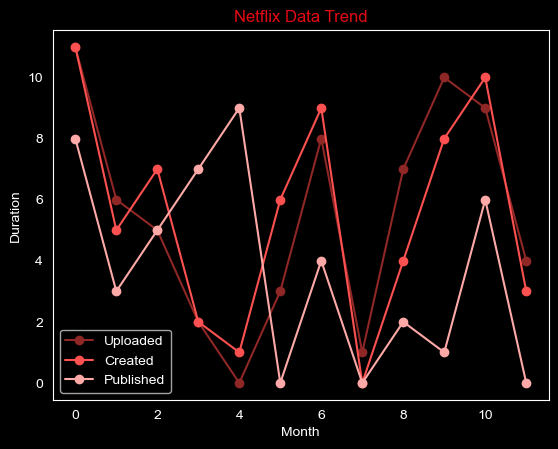

In [14]:

plt.plot(df['Month'], df['Total Uploaded Duration'], color='#8E2726', marker='o', label='Uploaded')
plt.plot(df['Month'], df['Total Created Duration'], color='#FC5150', marker='o', label='Created')
plt.plot(df['Month'], df['Total Published Duration'], color='#FCA9A8', marker='o', label='Published')

plt.xlabel("Month", color='white')
plt.ylabel("Duration", color='white')
plt.title("Netflix Data Trend", color='#E50914')
plt.legend()
plt.show()

In [18]:
#metric dictionary

metric_dictionary = pd.DataFrame({
    "Metric Name": [
        "Total Uploaded Duration",
        "Total Created Duration",
        "Total Published Duration"
    ],
    "Description": [
        "Total duration of content uploaded",
        "Total duration of content created",
        "Total duration of content published"
    ],
    "Unit": ["minutes", "minutes", "minutes"],
    "Type": ["Numeric", "Numeric", "Numeric"]
})

print("===== METRIC DICTIONARY =====")
print(metric_dictionary)

===== METRIC DICTIONARY =====
                Metric Name                          Description     Unit  \
0   Total Uploaded Duration   Total duration of content uploaded  minutes   
1    Total Created Duration    Total duration of content created  minutes   
2  Total Published Duration  Total duration of content published  minutes   

      Type  
0  Numeric  
1  Numeric  
2  Numeric  


In [19]:
# KPI CONSTRUCTION 

df['Upload Efficiency'] = df['Total Uploaded Duration'] / df['Total Created Duration']
df['Publishing Efficiency'] = df['Total Published Duration'] / df['Total Uploaded Duration']
df['Utilization Rate'] = df['Total Published Duration'] / df['Total Created Duration']

df['Created Growth (%)'] = df['Total Created Duration'].pct_change() * 100
df['Uploaded Growth (%)'] = df['Total Uploaded Duration'].pct_change() * 100


print("\n===== KPI DATA =====")
print(df[['Upload Efficiency',
          'Publishing Efficiency',
          'Utilization Rate',
          'Created Growth (%)',
          'Uploaded Growth (%)']])


# ----- KPI SUMMARY -----
kpi_summary = df[['Upload Efficiency',
                  'Publishing Efficiency',
                  'Utilization Rate']].mean()

print("\n===== KPI SUMMARY (AVERAGE) =====")
print(kpi_summary)


===== KPI DATA =====
    Upload Efficiency  Publishing Efficiency  Utilization Rate  \
0            1.000000               0.727273          0.727273   
1            1.200000               0.500000          0.600000   
2            0.714286               1.000000          0.714286   
3            1.000000               3.500000          3.500000   
4            0.000000                    inf          9.000000   
5            0.500000               0.000000          0.000000   
6            0.888889               0.500000          0.444444   
7                 inf               0.000000               NaN   
8            1.750000               0.285714          0.500000   
9            1.250000               0.100000          0.125000   
10           0.900000               0.666667          0.600000   
11           1.333333               0.000000          0.000000   

    Created Growth (%)  Uploaded Growth (%)  
0                  NaN                  NaN  
1           -54.545455     